# The Penny Beat — a quantitative teardown 🔬
### surprise-histogram discontinuity *z* · smooth-relabel placebo · penny-vs-decisive two-sample *t* · PEAD-composition decomposition · within-bin clean penalty · robustness sweep · costs & borrow · seed-robust control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Discontinuity_real%3F: Confirmed](https://img.shields.io/badge/Discontinuity_real%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We histogram earnings surprises, measure the +$0.01 discontinuity, test the penny-vs-decisive return spread, and — the honest bit — decompose that spread into a **management penalty** and a **mechanical PEAD composition** gap.

> ⚠️ **Not investment advice, and synthetic-only.** No free consensus-vs-actual EPS tape exists for a no-key stack, so the reproducible core is the deterministic synthetic world (seed 574, n=6000, panel fp `1ad98df82652`; as-of 2026-06-30). `HAVE_REAL` is always `False`; the Signal ceiling is `WEAK`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from penny_beat import data, strategy as st

# Synthetic-only study: the reproducible core IS the deterministic synthetic world.
PANEL, TRUTH = data.synthetic_panel()   # seed 574, spike=0.55, penny_penalty=-0.05
HAVE_REAL = False                       # no free consensus-vs-actual EPS tape exists
print("synthetic penny-beat panel:", len(PANEL), "firm-quarters | HAVE_REAL:", HAVE_REAL)
print("panel fingerprint:", data.fingerprint(PANEL))


synthetic penny-beat panel: 6000 firm-quarters | HAVE_REAL: False
panel fingerprint: 1ad98df82652


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Discontinuity z **+17.7** (placebo *p* 0.0005); penny−decisive spread **-4.92%** (*t* **-9.22**) — but composition-only spread **-1.83%** (*t* -3.48) ⇒ ~half is PEAD; and no real tape. |
| **Tradability** | `MIRAGE` | Unreachable licensed data; tiny per-quarter penny bucket; half the edge is harvestable drift. (Gross -4.92% → net harvest 4.47% at 5 bps/leg + 100 bps borrow — but the trade isn't the problem, the data is.) |
| **Discontinuity real?** | `CONFIRMED` | +1c excess **+606** (z +17.7), deficit ratio **0.48**; flat at the null (z +0.3 spike-off). |

> 💡 In plain words: the +1c spike is unmistakable and the engine is faithful (the control proves it), but the *return* penalty is half mechanical drift and can't be checked on a real tape — so `WEAK`, not `REAL`.

## 1 · The claim, steelmanned

Let $s_i$ be firm-quarter $i$'s rounded EPS surprise (cents) and $r_i$ its forward return.

- **H₁ (discontinuity).** The count at $s=+1$ exceeds a local smooth of its neighbours at $z \ge 2$ (an earnings-management spike).
- **H₂ (return penalty).** $\mathbb{E}[r \mid s=+1] - \mathbb{E}[r \mid s\ge+3] < 0$ at $t \le -2$ (penny-beaters underperform decisive beaters).
- **H₃ (separability).** The H₂ gap is a *management* penalty, **not** merely PEAD composition (i.e. it survives turning the manipulation knob to zero).
- **H₄ (net / tradable).** H₂ survives costs and a real, reachable data source.

On the synthetic tape we find **H₁ strongly supported** (z +17.7), **H₂ supported** (spread −4.9%, *t* −9.2), **H₃ only *partly*** (composition-only spread −1.8%, *t* −3.5 ⇒ ~half the gap is PEAD, not management), and **H₄ fails** (no reachable data). That partial H₃ + failed H₄ is exactly what caps the Signal at `WEAK`.

## 2 · So what? — what rides on each answer

The **discontinuity** is a celebrated, robust piece of evidence that earnings are managed in aggregate (Burgstahler-Dichev 1997) — the desk *confirms* it. The **return penalty** (Bhojraj et al. 2009) is the tradable claim, and it lives or dies on **separability**: a +1c surprise is mechanically a *smaller* surprise than a ≥+3c decisive beat, so under any post-earnings-announcement drift (PEAD; Bernard-Thomas 1989) the penny bucket drifts less *even absent management*. Only a within-threshold test (managed vs honest firms that both landed on +1c) isolates the management penalty — and that needs a label a real analyst never sees. Cousins: [229 Beneish](../../229-beneish-m-score/), [328 Benford](../../328-benford-law/).

## 3 · How we'd know — the protocol

- **Discontinuity.** $z = \dfrac{c(+1) - \tfrac12[c(0)+c(+2)]}{\sqrt{c(+1) + \tfrac14[c(0)+c(+2)]}}$ — excess mass at +1c over a local smooth, Poisson-standardised. Plus a **smooth-relabel placebo** (redraw the local histogram uniformly, read the +1c z's tail).
- **Return test.** Penny-beaters ($s=+1$) vs decisive beaters ($s\ge+3$): a two-sample (Welch) *t* on forward returns + a **label-shuffle placebo**.
- **Decomposition.** Re-run with `penny_penalty = 0` (spike still on) for the composition-only spread; and a **within-+1c-bin** managed-vs-honest test for the clean penalty (synthetic-truth diagnostic only).
- **Frictions.** Round-trip cost per leg + a borrow on the (short) penny leg.
- **Positive control.** Plant the effect and average the stats over 25 seeds (house rule); confirm the discontinuity z is flat at the null.

Timing: the surprise is public at the earnings release; the position is entered at that release close and held over the forward window — one documented execution lag, no look-ahead. The sweep and the control use the identical convention.

## 4 · The teardown

### 4a · The discontinuity — H₁

The surprise histogram with the +1c excess and the smooth-relabel placebo.

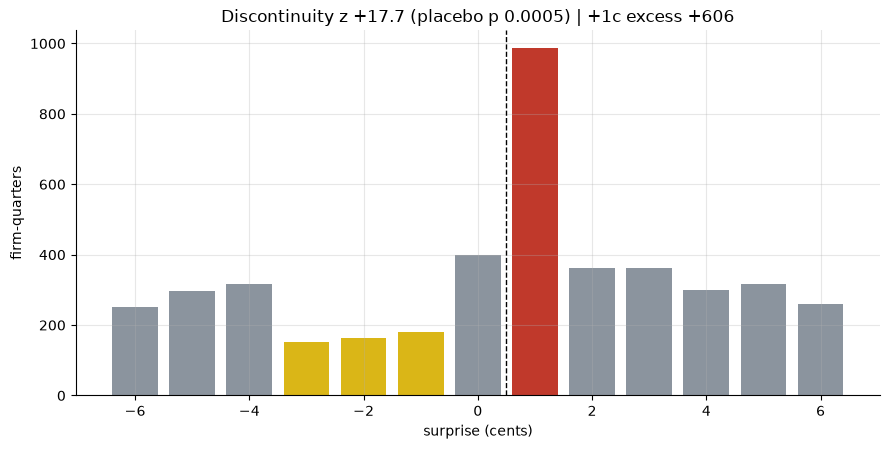

c(+1)=988  neigh~382  excess +606  z +17.67  placebo p 0.0005  deficit ratio 0.482


In [2]:
h = data.surprise_histogram(PANEL); sl = h.loc[-6:6]
dz = st.discontinuity_z(PANEL); dp = st.discontinuity_placebo_p(PANEL, n_perm=2000)
cols = [RED if k == 1 else (AMBER if k in (-1,-2,-3) else GREY) for k in sl.index]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(sl.index, sl.values, color=cols, width=.8)
ax.axvline(0.5, c='k', ls='--', lw=1)
ax.set_xlabel('surprise (cents)'); ax.set_ylabel('firm-quarters')
ax.set_title(f"Discontinuity z {dz['z']:+.1f} (placebo p {dp:.4f}) | +1c excess {dz['excess']:+.0f}")
plt.tight_layout(); plt.show()
print(f"c(+1)={dz['c_penny']:.0f}  neigh~{dz['neighbour_avg']:.0f}  excess {dz['excess']:+.0f}  "
      f"z {dz['z']:+.2f}  placebo p {dp:.4f}  deficit ratio {dz['deficit_ratio']:.3f}")

> 💡 In plain words: **H₁ supported, decisively.** z = **+17.7**, placebo *p* = 0.0005 — the +1c spike is not something a smooth distribution produces. The small-miss bins sit at 0.48× their mirror: mass moved *up* across zero.

### 4b · The return spread — H₂

Penny-beaters vs decisive beaters, two-sample *t* + placebo.

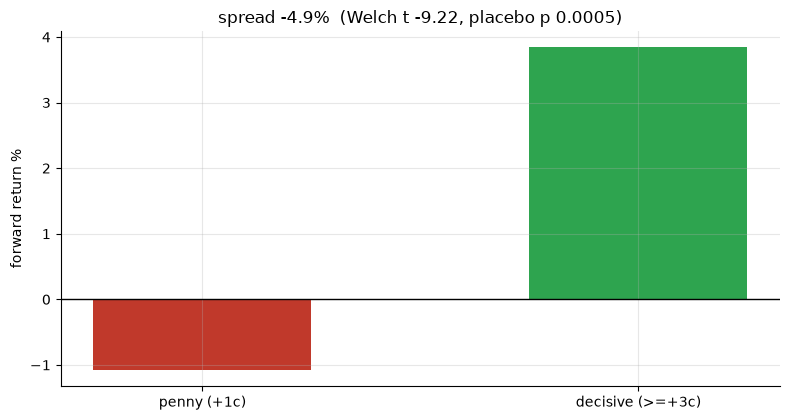

penny -1.07% (n=988) | decisive +3.84% (n=2067) | spread -4.92% | t -9.22 | placebo p 0.0005


In [3]:
b = st.penny_vs_decisive(PANEL); tt = st.spread_tstat(b)
rp = st.return_placebo_p(PANEL, n_perm=2000)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['penny (+1c)','decisive (>=+3c)'], [b['penny_mean']*100, b['decisive_mean']*100],
       color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f"spread {b['spread']*100:+.1f}%  (Welch t {tt['t']:+.2f}, placebo p {rp:.4f})")
plt.tight_layout(); plt.show()
print(f"penny {b['penny_mean']*100:+.2f}% (n={b['n_penny']}) | decisive {b['decisive_mean']*100:+.2f}% "
      f"(n={b['n_decisive']}) | spread {b['spread']*100:+.2f}% | t {tt['t']:+.2f} | placebo p {rp:.4f}")

> 💡 In plain words: **H₂ supported** on its face — penny-beaters trail by **-4.92%** (*t* -9.22, placebo *p* 0.0005). But *why*? That's 4c.

### 4c · Decomposition — H₃ (management vs mechanical drift)

Turn the manipulation knob to **zero** (spike still on): how much spread is left? Then isolate the clean penalty *within* the +1c bin (managed vs honest — a synthetic-truth diagnostic).

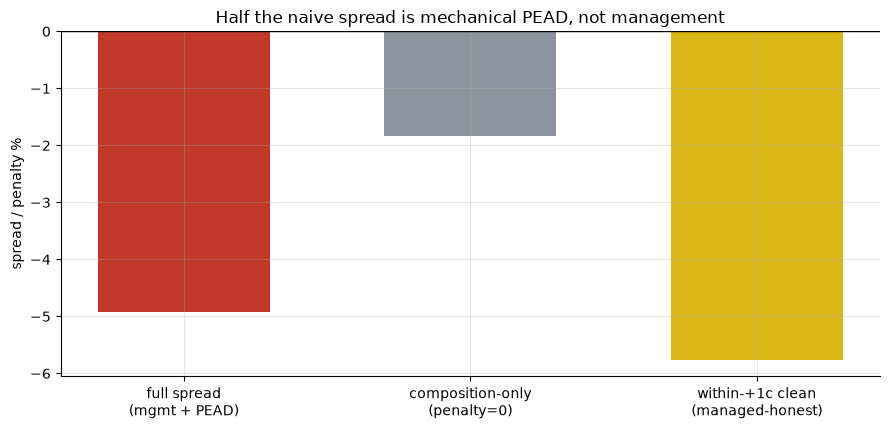

full spread (mgmt + PEAD)        -4.92%  (t -9.22)
composition-only (penalty=0)     -1.83%  (t -3.48)
within-+1c clean (managed-honest) -5.76%  (t -6.69)


In [4]:
pc, _ = data.synthetic_panel(penny_penalty=0.0)     # composition-only world
bc = st.penny_vs_decisive(pc); tc = st.spread_tstat(bc)
wb = st.within_bin_penalty(PANEL)                   # clean penalty, uses latent truth
rows = [('full spread\n(mgmt + PEAD)', b['spread']*100, tt['t']),
        ('composition-only\n(penalty=0)', bc['spread']*100, tc['t']),
        ('within-+1c clean\n(managed-honest)', wb['penalty']*100, wb['t'])]
labs = [r[0] for r in rows]; vals = [r[1] for r in rows]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(labs, vals, color=[RED, GREY, AMBER], width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('spread / penalty %')
ax.set_title('Half the naive spread is mechanical PEAD, not management')
plt.tight_layout(); plt.show()
for lab, v, t in rows: print(f"{lab.replace(chr(10),' '):32s} {v:+.2f}%  (t {t:+.2f})")

> 💡 In plain words: **H₃ only partly holds.** With manipulation *off* the spread is *still* **-1.83%** (*t* -3.48) — pure PEAD, because a 1c beat is a smaller surprise. The *clean* management penalty (within +1c, managed vs honest) is **-5.76%** (*t* -6.69) — but that needs a label no real analyst sees. The naive penny-minus-decisive spread over-states management by roughly 2×.

### 4d · Robustness — does the sign hold across management intensities?

Sweep the spike strength (holding the planted penalty fixed).

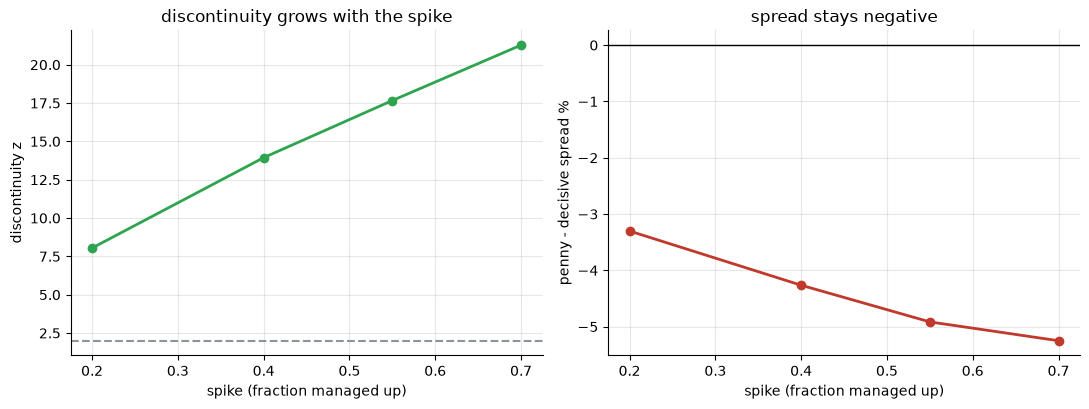

       disc_z  spread       t  n_penny
spike                                 
0.20    8.045  -0.033  -5.228      609
0.40   13.940  -0.043  -7.515      826
0.55   17.665  -0.049  -9.215      988
0.70   21.279  -0.052 -10.295     1165


In [5]:
sweep = st.robustness_sweep()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(sweep.index, sweep['disc_z'], 'o-', c=GREEN, lw=2); a1.axhline(2, ls='--', c=GREY)
a1.set_xlabel('spike (fraction managed up)'); a1.set_ylabel('discontinuity z'); a1.set_title('discontinuity grows with the spike')
a2.plot(sweep.index, sweep['spread']*100, 'o-', c=RED, lw=2); a2.axhline(0, c='k', lw=1)
a2.set_xlabel('spike (fraction managed up)'); a2.set_ylabel('penny - decisive spread %'); a2.set_title('spread stays negative')
plt.tight_layout(); plt.show()
print(sweep.round(3).to_string())

> 💡 In plain words: both the discontinuity z and the (negative) spread grow monotonically with the management intensity — the sign never flips. Stable *given the planted world* (this is an engine statement, not a real tape).

## 5 · The verdict

- **Signal `WEAK`** — H₁ strong (z +17.7), H₂ supported (spread -4.92%, *t* -9.22), but H₃ only partial (composition-only spread -1.83%) and H₄ fails (no real tape). Synthetic-only ⇒ ceiling `WEAK`.
- **Tradability `MIRAGE`** — unreachable data, tiny penny bucket, half the edge is harvestable drift.
- **Discontinuity real? `CONFIRMED`** — +1c excess +606 (z +17.7), flat at the null (z +0.3).

## 6 · Could you trade it? — costs and the borrow

Short penny-beaters, long decisive beaters. Costs are a footnote against the raw magnitude — but the real blocker is the data and the PEAD confound, not the friction.

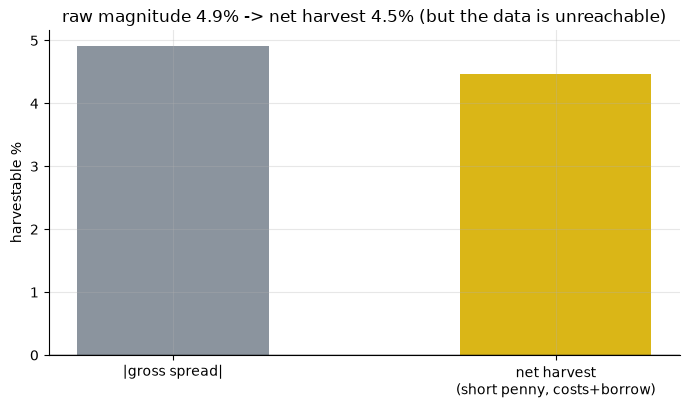

gross spread -4.92% | net harvest +4.47% (5 bps/leg + 100 bps borrow, 0.25y)


In [6]:
b = st.penny_vs_decisive(PANEL)
gross = b['spread']*100
net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=100.0, holding_years=0.25)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['|gross spread|','net harvest\n(short penny, costs+borrow)'], [abs(gross), net],
       color=[GREY, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('harvestable %')
ax.set_title(f'raw magnitude {abs(gross):.1f}% -> net harvest {net:.1f}% (but the data is unreachable)')
plt.tight_layout(); plt.show()
print(f'gross spread {gross:+.2f}% | net harvest {net:+.2f}% (5 bps/leg + 100 bps borrow, 0.25y)')

> 💡 In plain words: costs don't kill the *magnitude* — the data unavailability and the PEAD confound do. `MIRAGE`.

## 7 · Going further — the seed-robust synthetic positive control

Is the engine a faithful detector, or does it always print a spike? Plant a real penalty of increasing strength (spike fixed) and watch the penny−decisive *t* deepen — averaged over 25 seeds — while checking the discontinuity z is **flat at the joint null**.

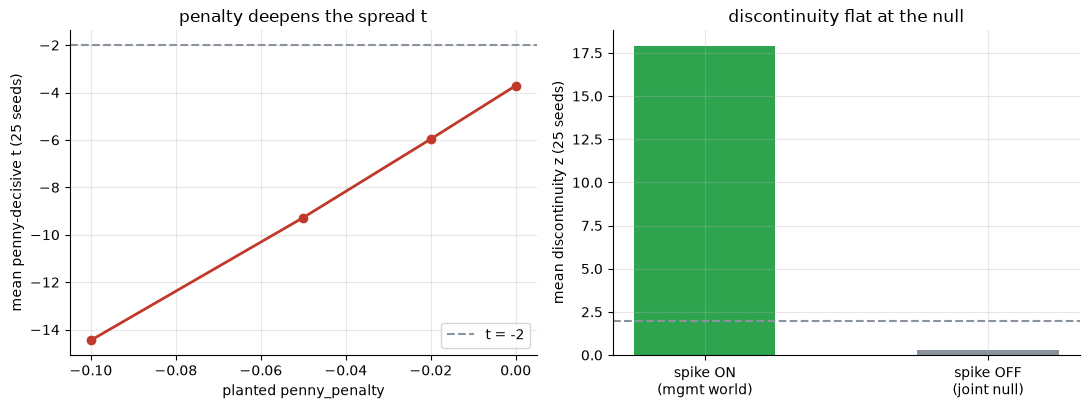

penalty +0.00 -> disc z +17.9, spread t -3.71
penalty -0.02 -> disc z +17.9, spread t -5.96
penalty -0.05 -> disc z +17.9, spread t -9.27
penalty -0.10 -> disc z +17.9, spread t -14.45
JOINT NULL (spike 0, penalty 0) -> disc z +0.3, spread t -2.34


In [7]:
pens = [0.0, -0.02, -0.05, -0.10]
ctrl = [st.synthetic_control(penny_penalty=p, spike=0.55, n_seeds=25) for p in pens]
zs = [c['mean_disc_z'] for c in ctrl]; ts = [c['mean_spread_t'] for c in ctrl]
nullc = st.synthetic_control(penny_penalty=0.0, spike=0.0, n_seeds=25)  # joint null
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(pens, ts, 'o-', c=RED, lw=2); a1.axhline(-2, ls='--', c=GREY, label='t = -2')
a1.set_xlabel('planted penny_penalty'); a1.set_ylabel('mean penny-decisive t (25 seeds)')
a1.set_title('penalty deepens the spread t'); a1.legend()
a2.bar(['spike ON\n(mgmt world)','spike OFF\n(joint null)'], [zs[0], nullc['mean_disc_z']],
       color=[GREEN, GREY], width=.5); a2.axhline(2, ls='--', c=GREY)
a2.set_ylabel('mean discontinuity z (25 seeds)'); a2.set_title('discontinuity flat at the null')
plt.tight_layout(); plt.show()
for p, c in zip(pens, ctrl): print(f'penalty {p:+.2f} -> disc z {c["mean_disc_z"]:+.1f}, spread t {c["mean_spread_t"]:+.2f}')
print(f'JOINT NULL (spike 0, penalty 0) -> disc z {nullc["mean_disc_z"]:+.1f}, spread t {nullc["mean_spread_t"]:+.2f}')

The discontinuity z is **≈ 0 at the joint null** (z +0.3, spike off) and jumps to ~18 once a spike is planted — a faithful, false-signal-free detector. The penny−decisive *t* deepens monotonically with the planted penalty; note it sits at ≈ -3.7 even at the *return* null (penalty 0) because of the PEAD composition floor. So the engine works — the ceiling here is set by the missing real tape and the composition confound, not the code. Cousins: [229 Beneish](../../229-beneish-m-score/), [328 Benford](../../328-benford-law/).